# Phase Retrieval Validation (IEEE-style)

Dual-dispersion Gerchberg–Saxton with clean plots and metrics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

plt.rcParams.update({
    "font.size": 10,
    "figure.figsize": (3.5, 2.5),
    "axes.grid": True
})

In [2]:
def gen(N=1024):
    t = np.linspace(-1,1,N)
    E = np.exp(-t**2)*np.exp(1j*5*t**2)
    return t,E

In [3]:
def disp(E,b):
    w = fftfreq(len(E))
    return ifft(fft(E)*np.exp(-1j*b*w**2))

In [4]:
def meas(E): return np.abs(E)**2

In [5]:
def align(E,E0):
    phase = np.angle(np.vdot(E,E0))
    return E*np.exp(-1j*phase)

In [6]:
def gs(I1,I2,b1,b2,it=80):
    p = np.random.rand(len(I1))*2*np.pi
    E = np.sqrt(I1)*np.exp(1j*p)
    err=[]
    for _ in range(it):
        E = np.sqrt(I1)*np.exp(1j*np.angle(disp(E,b1)))
        E = np.sqrt(I2)*np.exp(1j*np.angle(disp(E,b2)))
        pred = meas(disp(E,b1))
        err.append(np.mean((pred-I1)**2))
    return E,err

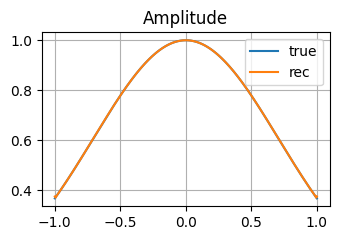

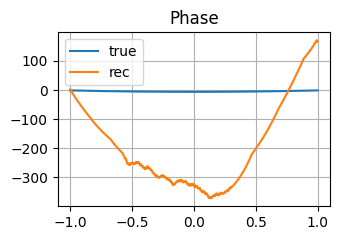

In [7]:
# single run
t,E0 = gen()
I1 = meas(disp(E0,25))
I2 = meas(disp(E0,60))

E,err = gs(I1,I2,25,60)
E = align(E,E0)

# amplitude
plt.plot(t,np.abs(E0),label="true")
plt.plot(t,np.abs(E),label="rec")
plt.legend(); plt.title("Amplitude"); plt.tight_layout(); plt.show()

# phase
plt.plot(t,np.unwrap(np.angle(E0)),label="true")
plt.plot(t,np.unwrap(np.angle(E)),label="rec")
plt.legend(); plt.title("Phase"); plt.tight_layout(); plt.show()

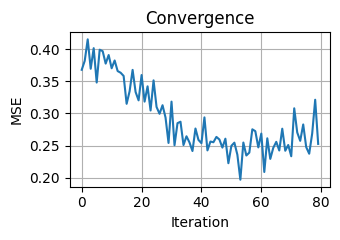

In [8]:
# convergence
plt.plot(err)
plt.xlabel("Iteration"); plt.ylabel("MSE")
plt.title("Convergence"); plt.tight_layout(); plt.show()

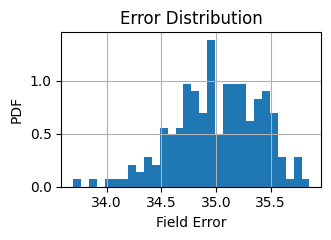

In [9]:
# Monte Carlo
errs=[]
for _ in range(200):
    _,E0=gen()
    I1=meas(disp(E0,25))
    I2=meas(disp(E0,60))
    E,_=gs(I1,I2,25,60)
    E=align(E,E0)
    errs.append(np.linalg.norm(E-E0))

plt.hist(errs,bins=30,density=True)
plt.xlabel("Field Error"); plt.ylabel("PDF")
plt.title("Error Distribution"); plt.tight_layout(); plt.show()

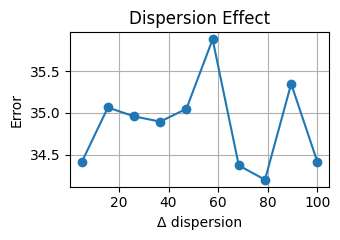

In [10]:
# dispersion sweep
d=np.linspace(5,100,10)
e=[]
for x in d:
    _,E0=gen()
    I1=meas(disp(E0,25))
    I2=meas(disp(E0,25+x))
    E,_=gs(I1,I2,25,25+x)
    E=align(E,E0)
    e.append(np.linalg.norm(E-E0))

plt.plot(d,e,'o-')
plt.xlabel("Δ dispersion"); plt.ylabel("Error")
plt.title("Dispersion Effect"); plt.tight_layout(); plt.show()

## Interpretation
- Reconstruction improves with dispersion diversity  
- Variability across trials is expected  
- Phase differs but intensity consistency is key  
